# Distribution Types

### Distribution Types — shape, properties, and when each is used

Understanding distribution shape is the first step in anomaly detection. The distribution tells you what is "normal" — deviations from that shape are potential anomalies.

This notebook demonstrates the four core distribution types from the anomaly detection guide: **Uniform**, **Normal**, **Exponential**, and **Lognormal**.

#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
np.random.seed(42)

### Uniform Distribution

**Shape:** Flat, constant height. Every value in the range is equally likely.

`np.random.uniform(low, high, size)` — samples uniformly between `low` and `high`.

**Use when:** Random sampling, simulations, baseline comparisons. No natural clustering — anomalies are any value outside the known bounds.

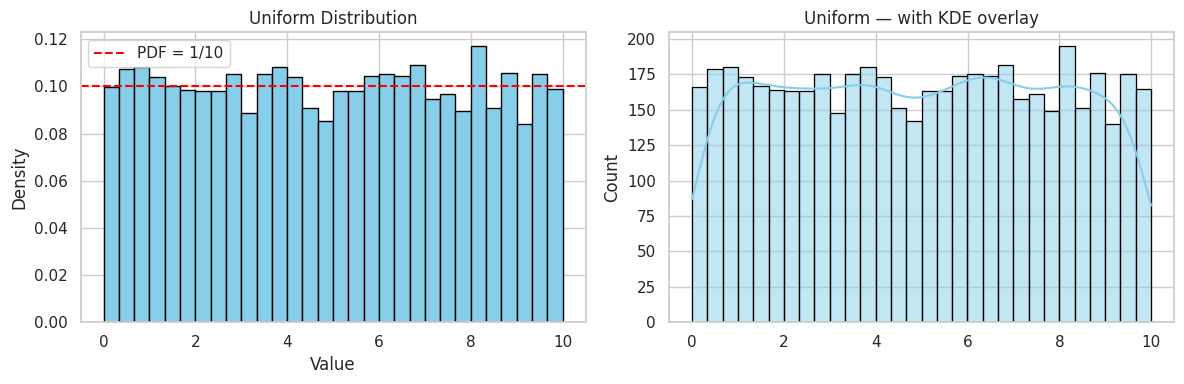

In [2]:
# Uniform distribution
low, high = 0, 10
uniform_data = np.random.uniform(low, high, 5000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(uniform_data, bins=30, color='skyblue', edgecolor='black', density=True)
axes[0].axhline(1 / (high - low), color='red', ls='--', label=f'PDF = 1/{high-low}')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].set_title('Uniform Distribution')
axes[0].legend()

# KDE
sns.histplot(uniform_data, bins=30, kde=True, color='skyblue', edgecolor='black', ax=axes[1])
axes[1].set_title('Uniform — with KDE overlay')

plt.tight_layout()
plt.show()

### Normal (Gaussian) Distribution

**Shape:** Bell-shaped, symmetric. Mean = median = mode.

`np.random.normal(loc, scale, size)` — `loc` = mean, `scale` = std dev, `size` = sample count.

**68–95–99.7 rule:** ~68% of data within 1 std dev, ~95% within 2, ~99.7% within 3.

**Use when:** Natural measurements (height, error), many statistical methods assume this. Anomalies are values beyond ~3 std dev from the mean.

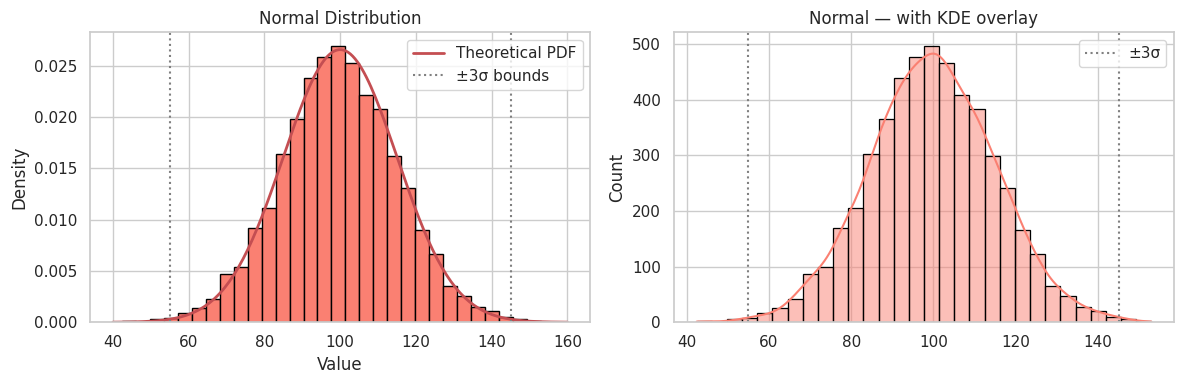

In [3]:
# Normal distribution
mu, sigma = 100, 15
normal_data = np.random.normal(mu, sigma, 5000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with theoretical PDF
axes[0].hist(normal_data, bins=30, color='salmon', edgecolor='black', density=True)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='Theoretical PDF')
axes[0].axvline(mu - 3*sigma, color='gray', ls=':', label='\u00b13\u03c3 bounds')
axes[0].axvline(mu + 3*sigma, color='gray', ls=':')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].set_title('Normal Distribution')
axes[0].legend()

# KDE with 3-sigma bounds
sns.histplot(normal_data, bins=30, kde=True, color='salmon', edgecolor='black', ax=axes[1])
axes[1].axvline(mu - 3*sigma, color='gray', ls=':', label='\u00b13\u03c3')
axes[1].axvline(mu + 3*sigma, color='gray', ls=':')
axes[1].set_title('Normal — with KDE overlay')
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
# Flag potential outliers using Z-score
z_scores = np.abs(stats.zscore(normal_data))
outliers = normal_data[z_scores > 3]
print(f'Normal data: {len(normal_data)} samples')
print(f'Outliers (|z| > 3): {len(outliers)} ({100*len(outliers)/len(normal_data):.2f}%)')
print(f'Expected under normal: ~0.27%')

Normal data: 5000 samples
Outliers (|z| > 3): 16 (0.32%)
Expected under normal: ~0.27%


### Exponential Distribution

**Shape:** Starts high at zero, decays exponentially to the right. Positive skew, memoryless property.

`np.random.exponential(scale, size)` — `scale` = 1/λ (mean and std dev are both `scale`).

**Use when:** Modelling time between events (arrivals, failures, requests), queuing theory, survival analysis.

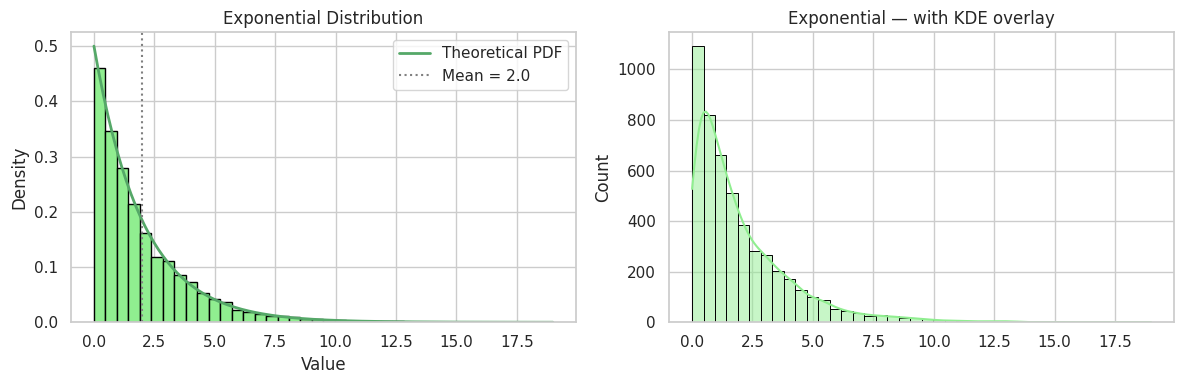

In [5]:
# Exponential distribution
scale = 2.0  # mean = 2
exp_data = np.random.exponential(scale, 5000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with theoretical PDF
axes[0].hist(exp_data, bins=40, color='lightgreen', edgecolor='black', density=True)
x = np.linspace(0, exp_data.max(), 200)
axes[0].plot(x, stats.expon.pdf(x, scale=scale), 'g-', lw=2, label='Theoretical PDF')
axes[0].axvline(scale, color='gray', ls=':', label=f'Mean = {scale}')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].set_title('Exponential Distribution')
axes[0].legend()

# KDE
sns.histplot(exp_data, bins=40, kde=True, color='lightgreen', edgecolor='black', ax=axes[1])
axes[1].set_title('Exponential — with KDE overlay')

plt.tight_layout()
plt.show()

### Lognormal Distribution

**Shape:** Right-skewed with a long tail. The logarithm of the data follows a normal distribution. Values are always positive.

`np.random.lognormal(mean, sigma, size)` — `mean` and `sigma` are the mean and std dev of the underlying normal.

**Use when:** Income, stock prices, property values, response times — data that clusters low but can spike high. Common in real-world anomaly detection.

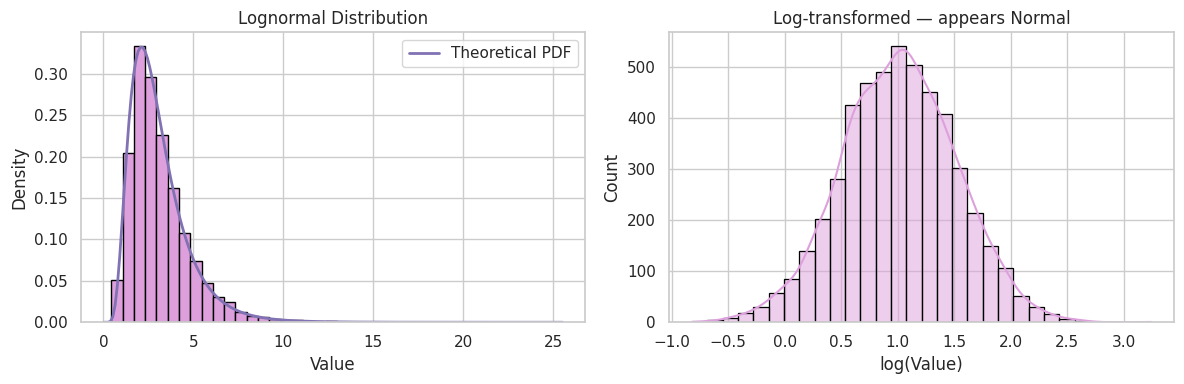

In [6]:
# Lognormal distribution
mu_ln, sigma_ln = 1.0, 0.5  # log-normal parameters
lognormal_data = np.random.lognormal(mu_ln, sigma_ln, 5000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with theoretical PDF
axes[0].hist(lognormal_data, bins=40, color='plum', edgecolor='black', density=True)
x = np.linspace(0.01, lognormal_data.max(), 200)
axes[0].plot(x, stats.lognorm.pdf(x, s=sigma_ln, scale=np.exp(mu_ln)), 'm-', lw=2, label='Theoretical PDF')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].set_title('Lognormal Distribution')
axes[0].legend()

# Log-transformed view (appears normal)
log_transformed = np.log(lognormal_data)
sns.histplot(log_transformed, bins=30, kde=True, color='plum', edgecolor='black', ax=axes[1])
axes[1].set_xlabel('log(Value)')
axes[1].set_title('Log-transformed — appears Normal')

plt.tight_layout()
plt.show()

### Side-by-Side Comparison

All four distributions at the same scale for easy comparison.

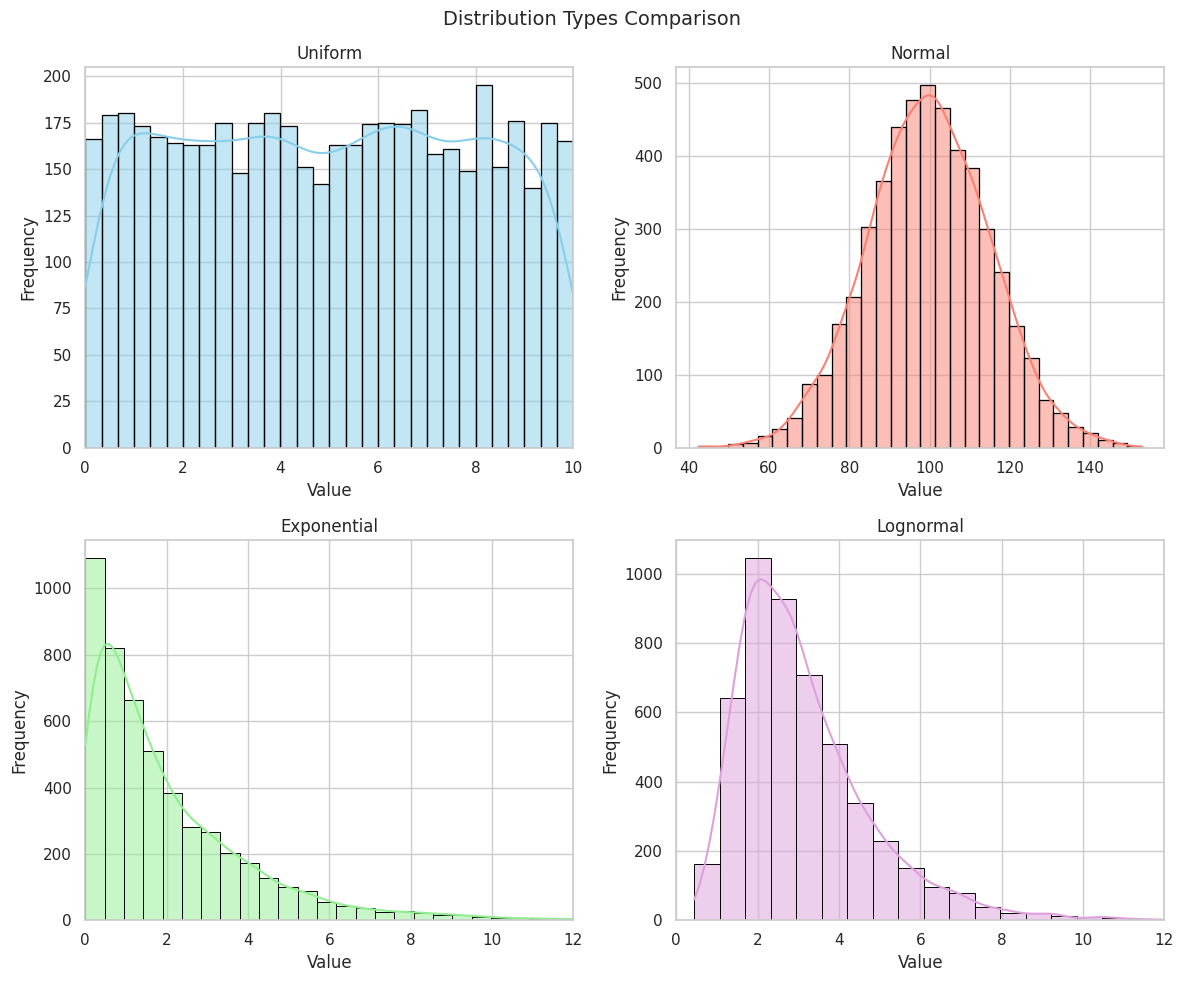

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

distributions = [
    (uniform_data, 'Uniform', 30, 'skyblue', (0, 10)),
    (normal_data, 'Normal', 30, 'salmon', None),
    (exp_data, 'Exponential', 40, 'lightgreen', (0, 12)),
    (lognormal_data, 'Lognormal', 40, 'plum', (0, 12)),
]

for ax, (data, name, bins, color, xlim) in zip(axes.ravel(), distributions):
    sns.histplot(data, bins=bins, kde=True, color=color, edgecolor='black', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    if xlim:
        ax.set_xlim(xlim)

plt.suptitle('Distribution Types Comparison', fontsize=14)
plt.tight_layout()
plt.show()

### Summary Table

| Distribution | Shape | Properties | Use When |
|-------------|-------|------------|-----------|
| **Uniform** | Flat, constant height | Every value equally likely, no peaks | Random sampling, simulations, baseline comparisons |
| **Normal** | Bell-shaped, symmetric | Mean = median = mode, 68-95-99.7 rule | Natural measurements (height, error), most statistical methods assume this |
| **Exponential** | Starts high, decays right | Positive skew, memoryless, models waiting times | Time between events (arrivals, failures, requests) |
| **Lognormal** | Right-skewed, long tail | Logarithm is normal, values are positive | Income, stock prices, property values — cluster low but can spike high |